<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02f%20adaline%20with%20SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

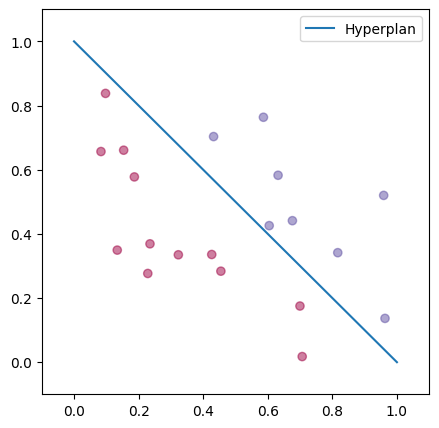

In [195]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20):
  X = np.random.rand(n,2)
  coefs = np.array([1, 1])
  intercept = 1
  labels = X @ coefs - intercept
  y = np.array(labels>0, dtype=int)*2-1
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="Hyperplan"):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, label=legend)
  plt.legend()

X, y = createDataset()
plotDataset(X, y)
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 1.0
Weights: [-2.91915097  3.32401019  2.634041  ]


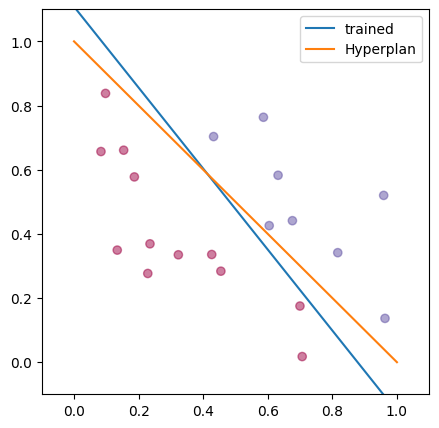

In [196]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class Adaline(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000, learning_rate=0.01):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = np.zeros(X.shape[1])
    for _ in range(self.max_iter):
      y_pred = X @ self.w_
      error = y - y_pred
      self.w_ += self.learning_rate * error @ X
    return self

  def pre_activation(self, X):
    X = include_bias(X)
    return X @ self.w_

  def predict(self, X):
    return np.sign(self.pre_activation(X))

clf = Adaline()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_[1:], clf.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 0.953


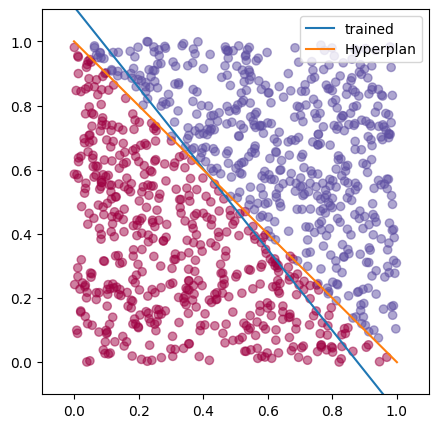

In [197]:
X_test, y_test = createDataset(n=1000)
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf.w_[1:], clf.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 0.9666666666666667
Weights: [-1.48016608  1.94044677  0.59341108]


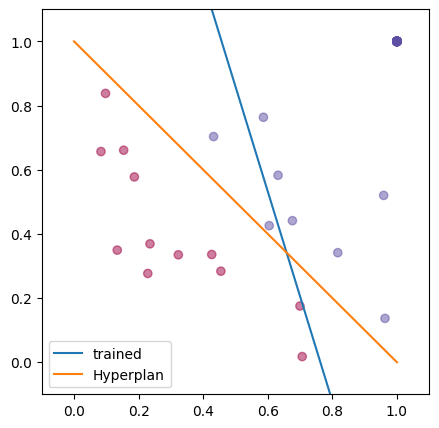

In [226]:
X_bad = np.concatenate((X,np.ones_like(X)))
y_bad = np.concatenate((y,np.ones_like(y)))
X_bad = np.concatenate((X_bad,np.ones_like(X)))
y_bad = np.concatenate((y_bad,np.ones_like(y)))
clf_bad = Adaline()
clf_bad.fit(X_bad, y_bad)
y_pred = clf_bad.predict(X_bad)
print(f"Accuracy: {accuracy_score(y_bad, y_pred)}")
print(f"Weights: {clf_bad.w_}")
plotDataset(X_bad, y_bad)
plotHyperplan(clf_bad.w_[1:], clf_bad.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 0.811


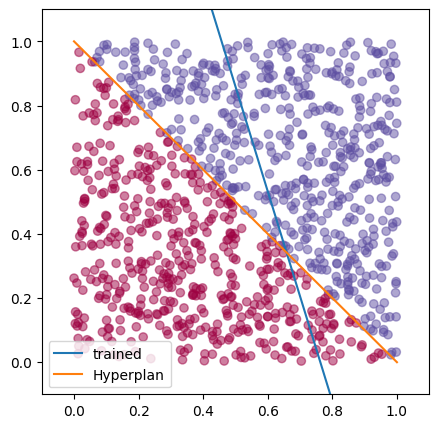

In [227]:
X_test, y_test = createDataset(n=1000)
y_pred = clf_bad.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf_bad.w_[1:], clf_bad.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()